<a href="https://colab.research.google.com/github/MohdFuzailHaider/flyrank/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Dataset Loading

In [1]:
from google.colab import userdata
from huggingface_hub import hf_hub_download
import pandas as pd

HF_TOKEN = userdata.get("HF_TOKEN")

def load_month(month):
    path = hf_hub_download(
        repo_id="FlyRank/internship-warehouse",
        repo_type="dataset",
        filename=f"fact_content_daily_performance/month={month}/data_0.parquet",
        token=HF_TOKEN,)

    return pd.read_parquet(path)
mar = load_month("2026-03")

print(mar.shape)

(9841378, 30)


In [5]:
mar.head()

,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,...,sessions_paid,sessions_ai,ai_chatgpt,ai_perplexity,ai_gemini,ai_copilot,ai_claude,ai_meta,ai_other,scroll_events
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,None,20,0,67,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,None,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,None,125,1,616,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,None,7,0,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,None,11,0,25,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
mar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9841378 entries, 0 to 9841377
Data columns (total 30 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   report_date               object 
 1   client_hash_id            object 
 2   content_hash_id           object 
 3   client_has_gsc            bool   
 4   client_has_ga4            bool   
 5   gsc_data_available        bool   
 6   ga4_data_available        object 
 7   gsc_impressions           int64  
 8   gsc_clicks                int64  
 9   gsc_sum_position          int64  
 10  gsc_avg_position          float64
 11  ga4_pageviews             float64
 12  ga4_sessions              float64
 13  ga4_users                 float64
 14  ga4_engaged_sessions      float64
 15  ga4_total_engagement_sec  float64
 16  sessions_organic          float64
 17  sessions_direct           float64
 18  sessions_referral         float64
 19  sessions_social           float64
 20  sessions_paid           

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

* My project is primarily a scoring and ranking task.
* The goal is to assign each each conent page a priority score based on observable search performance signals and rank pages so that the SEO and content team can review the highest-priority pages first.
* I will use Logistic Regression as the underlying classification method.
* The model will predict the probability that a content page belongs to the target class based on signals available before the prediction window.
* I will then use this predicted probability as a priority score to rank pages.
* Logistic Regression is a suitable first method because it is relatively simple, interpretable, and directly produces probabilities that can be used for ranking.
* This allow me to test whether as ML-based scoring approach improves on my Week 4 rule-based baseline without adding unnecessary complexity.
* The final output is therefore a ranked decision-support queue, rather than only a yes/no classification.

## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

* I use a grouped train/test split based on client_hash_id.
* Mutiple content pages can belong to the same client, and pages from the same client may share similar traffic and performance patters.
* A random split could place pages from the same client in both training and test data, making evaluation overly optimistic.
* Therefore, the training and test sets contain different clients.
* The client_hash_id is used only to define the groups and is not used as a model feature. The split tests whether the approach can generalize to pages from clients not seen during training.

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [6]:
mar[["client_hash_id", "content_hash_id"]].nunique()

,0
client_hash_id,55
content_hash_id,331437


In [7]:
mar.groupby(["client_hash_id", "content_hash_id"]).size().describe()

,0
count,331437.000000
mean,29.693058
std,4.738734
min,1.000000
25%,31.000000
50%,31.000000
75%,31.000000
max,31.000000


In [8]:
page_df = (mar.groupby(["client_hash_id", "content_hash_id"], as_index=False).agg(
        impressions=("gsc_impressions", "sum"),
        clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
        pageviews=("ga4_pageviews", "sum"),
        sessions=("ga4_sessions", "sum"),
        users=("ga4_users", "sum"),
        engaged_sessions=("ga4_engaged_sessions", "sum"),
        engagement_sec=("ga4_total_engagement_sec", "sum"),
        organic_sessions=("sessions_organic", "sum"),
        scroll_events=("scroll_events", "sum"),))

print(page_df.shape)
page_df.head()

(331437, 12)


,client_hash_id,content_hash_id,impressions,clicks,avg_position,pageviews,sessions,users,engaged_sessions,engagement_sec,organic_sessions,scroll_events
0,client_0797ff3a1fc9a6a5,content_004e9c4c32e88631,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,client_0797ff3a1fc9a6a5,content_0236ef736698e17c,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,client_0797ff3a1fc9a6a5,content_025f6cfd3c298870,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,client_0797ff3a1fc9a6a5,content_0263d5f9b7a2ecd4,1,0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,client_0797ff3a1fc9a6a5,content_02752c6c1c60161f,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
page_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331437 entries, 0 to 331436
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   client_hash_id    331437 non-null  object 
 1   content_hash_id   331437 non-null  object 
 2   impressions       331437 non-null  int64  
 3   clicks            331437 non-null  int64  
 4   avg_position      176738 non-null  float64
 5   pageviews         331437 non-null  float64
 6   sessions          331437 non-null  float64
 7   users             331437 non-null  float64
 8   engaged_sessions  331437 non-null  float64
 9   engagement_sec    331437 non-null  float64
 10  organic_sessions  331437 non-null  float64
 11  scroll_events     331437 non-null  float64
dtypes: float64(8), int64(2), object(2)
memory usage: 30.3+ MB


In [19]:
page_df.describe()

,impressions,clicks,avg_position,pageviews,sessions,users,engaged_sessions,engagement_sec,organic_sessions,scroll_events
count,331437.000000,331437.000000,176738.000000,331437.000000,331437.000000,331437.000000,331437.000000,331437.000000,331437.000000,331437.000000
mean,846.790156,2.479602,15.999277,4.480055,3.921735,3.830665,0.089160,14.386982,1.766272,0.664087
std,4044.514753,19.651282,17.686260,28.321687,25.381883,25.005604,0.879657,153.449153,15.529422,4.862806
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,5.001970,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,8.505296,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,216.000000,0.000000,20.369190,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
max,617124.000000,5668.000000,309.000000,2879.000000,2730.000000,2648.000000,224.000000,43551.000000,3171.000000,667.000000


In [20]:
mar["report_date"] = pd.to_datetime(mar["report_date"])

early = mar[(mar["report_date"] >= "2026-03-01") &
    (mar["report_date"] <= "2026-03-15")].copy()

late = mar[(mar["report_date"] >= "2026-03-16") &
    (mar["report_date"] <= "2026-03-31")].copy()

print("Early shape:", early.shape)
print("Late shape:", late.shape)

Early shape: (4642255, 30)
Late shape: (5199123, 30)


In [21]:
print("Early period:")
print(early["report_date"].min(), "to", early["report_date"].max())

print("\nLate period:")
print(late["report_date"].min(), "to", late["report_date"].max())

Early period:
2026-03-01 00:00:00 to 2026-03-15 00:00:00

Late period:
2026-03-16 00:00:00 to 2026-03-31 00:00:00


In [22]:
early_features = (
    early.groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(
        impressions=("gsc_impressions", "sum"),
        clicks=("gsc_clicks", "sum"),
        avg_position=("gsc_avg_position", "mean"),
        pageviews=("ga4_pageviews", "sum"),
        sessions=("ga4_sessions", "sum"),
        users=("ga4_users", "sum"),
        engaged_sessions=("ga4_engaged_sessions", "sum"),
        engagement_sec=("ga4_total_engagement_sec", "sum"),
        organic_sessions=("sessions_organic", "sum"),
        scroll_events=("scroll_events", "sum"),
    )
)

print(early_features.shape)
early_features.head()

(319759, 12)


,client_hash_id,content_hash_id,impressions,clicks,avg_position,pageviews,sessions,users,engaged_sessions,engagement_sec,organic_sessions,scroll_events
0,client_0797ff3a1fc9a6a5,content_004e9c4c32e88631,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,client_0797ff3a1fc9a6a5,content_0236ef736698e17c,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,client_0797ff3a1fc9a6a5,content_025f6cfd3c298870,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,client_0797ff3a1fc9a6a5,content_0263d5f9b7a2ecd4,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,client_0797ff3a1fc9a6a5,content_02752c6c1c60161f,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
late_features = (
    late.groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(
        late_impressions=("gsc_impressions", "sum"),
        late_clicks=("gsc_clicks", "sum"),
        late_avg_position=("gsc_avg_position", "mean"),
        late_pageviews=("ga4_pageviews", "sum"),
        late_sessions=("ga4_sessions", "sum"),
        late_users=("ga4_users", "sum"),
        late_engaged_sessions=("ga4_engaged_sessions", "sum"),
        late_engagement_sec=("ga4_total_engagement_sec", "sum"),
        late_organic_sessions=("sessions_organic", "sum"),
        late_scroll_events=("scroll_events", "sum"),
    )
)

print(late_features.shape)
late_features.head()

(331436, 12)


,client_hash_id,content_hash_id,late_impressions,late_clicks,late_avg_position,late_pageviews,late_sessions,late_users,late_engaged_sessions,late_engagement_sec,late_organic_sessions,late_scroll_events
0,client_0797ff3a1fc9a6a5,content_004e9c4c32e88631,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,client_0797ff3a1fc9a6a5,content_0236ef736698e17c,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,client_0797ff3a1fc9a6a5,content_025f6cfd3c298870,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,client_0797ff3a1fc9a6a5,content_0263d5f9b7a2ecd4,1,0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,client_0797ff3a1fc9a6a5,content_02752c6c1c60161f,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
model_df = early_features.merge(
    late_features[
        ["client_hash_id", "content_hash_id", "late_impressions"]
    ],
    on=["client_hash_id", "content_hash_id"],
    how="left"
)

# Pages missing from the late period had no recorded late impressions
model_df["late_impressions"] = model_df["late_impressions"].fillna(0)

print(model_df.shape)
model_df.head()

(319759, 13)


,client_hash_id,content_hash_id,impressions,clicks,avg_position,pageviews,sessions,users,engaged_sessions,engagement_sec,organic_sessions,scroll_events,late_impressions
0,client_0797ff3a1fc9a6a5,content_004e9c4c32e88631,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,client_0797ff3a1fc9a6a5,content_0236ef736698e17c,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,client_0797ff3a1fc9a6a5,content_025f6cfd3c298870,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,client_0797ff3a1fc9a6a5,content_0263d5f9b7a2ecd4,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,client_0797ff3a1fc9a6a5,content_02752c6c1c60161f,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
model_df["early_daily_impressions"] = model_df["impressions"] / 15
model_df["late_daily_impressions"] = model_df["late_impressions"] / 16

model_df["is_declining"] = (
    (model_df["impressions"] > 0) &
    (model_df["late_daily_impressions"] < model_df["early_daily_impressions"])
).astype(int)

model_df["is_declining"].value_counts()

,count
is_declining,
0,244254
1,75505


In [26]:
model_df["is_declining"].value_counts(normalize=True) * 100

,proportion
is_declining,
0,76.386904
1,23.613096


In [28]:
feature_cols = [
    "impressions",
    "clicks",
    "avg_position",
    "pageviews",
    "sessions",
    "users",
    "engaged_sessions",
    "engagement_sec",
    "organic_sessions",
    "scroll_events"
]

X = model_df[feature_cols]
y = model_df["is_declining"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X.head()

X shape: (319759, 10)
y shape: (319759,)


,impressions,clicks,avg_position,pageviews,sessions,users,engaged_sessions,engagement_sec,organic_sessions,scroll_events
0,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
X.isna().sum()

,0
impressions,0
clicks,0
avg_position,167778
pageviews,0
sessions,0
users,0
engaged_sessions,0
engagement_sec,0
organic_sessions,0
scroll_events,0


In [30]:
X = X.copy()

X["avg_position"] = X["avg_position"].fillna(
    X["avg_position"].median()
)

X.isna().sum()

,0
impressions,0
clicks,0
avg_position,0
pageviews,0
sessions,0
users,0
engaged_sessions,0
engagement_sec,0
organic_sessions,0
scroll_events,0


In [31]:
model_df.groupby("client_hash_id").size().describe()

,0
count,52.000000
mean,6149.211538
std,8387.298834
min,11.000000
25%,535.250000
50%,3054.500000
75%,7059.750000
max,31887.000000


In [32]:
from sklearn.model_selection import GroupShuffleSplit

groups = model_df["client_hash_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining clients:", groups.iloc[train_idx].nunique())
print("Test clients:", groups.iloc[test_idx].nunique())

Training set: (265352, 10)
Test set: (54407, 10)

Training clients: 41
Test clients: 11


In [33]:
train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])

overlap = train_clients.intersection(test_clients)

print("Clients appearing in both sets:", len(overlap))
print("Overlap:", overlap)

Clients appearing in both sets: 0
Overlap: set()


In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Predictions
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.7439851489698017
Precision: 0.33353211790765036
Recall: 0.39067957289691646
F1 Score: 0.3598510960981663
ROC-AUC: 0.6232279187526768

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.82      0.84     44386
           1       0.33      0.39      0.36     10021

    accuracy                           0.74     54407
   macro avg       0.60      0.61      0.60     54407
weighted avg       0.76      0.74      0.75     54407



In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [37]:
# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.7204036245336078
Precision: 0.3965400406585084
Recall: 0.9927152978744637
F1 Score: 0.5667084425202233
ROC-AUC: 0.8491926799168508

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.66      0.79     44386
           1       0.40      0.99      0.57     10021

    accuracy                           0.72     54407
   macro avg       0.70      0.83      0.68     54407
weighted avg       0.89      0.72      0.75     54407



[[29247 15139]
 [   73  9948]]


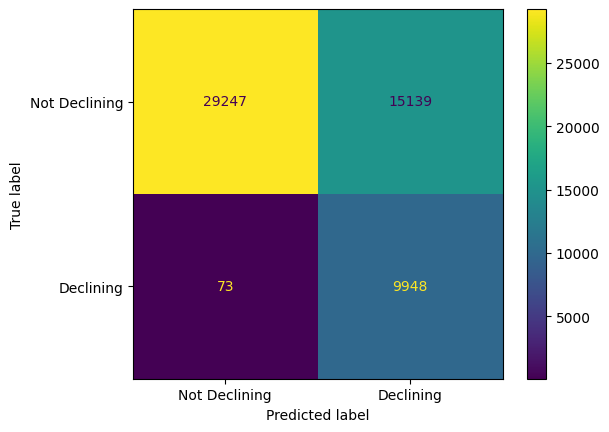

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Declining", "Declining"]
).plot()

In [40]:
print("Actual declining rate:")
print(y_test.mean())

print("\nPredicted declining rate:")
print(rf_pred.mean())

Actual declining rate:
0.18418585843733343

Predicted declining rate:
0.4610987556748213


In [41]:
from sklearn.ensemble import RandomForestClassifier

rf_model_2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model_2.fit(X_train, y_train)

print("Random Forest trained!")

Random Forest trained!


In [42]:
rf2_pred = rf_model_2.predict(X_test)
rf2_prob = rf_model_2.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf2_pred))
print("Precision:", precision_score(y_test, rf2_pred))
print("Recall:", recall_score(y_test, rf2_pred))
print("F1 Score:", f1_score(y_test, rf2_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf2_prob))

Accuracy: 0.7727865899608506
Precision: 0.42692139601673224
Recall: 0.6823670292385989
F1 Score: 0.5252323527152624
ROC-AUC: 0.8462318123964188


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

rf2_pred = rf_model_2.predict(X_test)
rf2_prob = rf_model_2.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf2_pred))
print("Precision:", precision_score(y_test, rf2_pred))
print("Recall:", recall_score(y_test, rf2_pred))
print("F1 Score:", f1_score(y_test, rf2_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf2_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, rf2_pred))

Accuracy: 0.7727865899608506
Precision: 0.42692139601673224
Recall: 0.6823670292385989
F1 Score: 0.5252323527152624
ROC-AUC: 0.8462318123964188

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.79      0.85     44386
           1       0.43      0.68      0.53     10021

    accuracy                           0.77     54407
   macro avg       0.67      0.74      0.69     54407
weighted avg       0.83      0.77      0.79     54407



In [48]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nFirst 5 test indices:")
print(X_test.index[:5])

X_test shape: (54407, 10)
y_test shape: (54407,)

First 5 test indices:
Index([27910, 27911, 27912, 27913, 27914], dtype='int64')


In [49]:
test_data = model_df.loc[X_test.index].copy()

print(test_data.shape)
test_data[["impressions", "is_declining"]].head()

(54407, 16)


,impressions,is_declining
27910,0,0
27911,0,0
27912,29,0
27913,0,0
27914,0,0


In [50]:
test_data["baseline_score"] = test_data["impressions"]
def precision_at_k(y_true, scores, k):
    results = pd.DataFrame({
        "actual": y_true,
        "score": scores
    })

    top_k = results.sort_values("score", ascending=False).head(k)

    return top_k["actual"].mean()

In [51]:
# Logistic Regression probabilities
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

# Random Forest (balanced) probabilities
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Random Forest (normal) probabilities
rf2_prob = rf_model_2.predict_proba(X_test)[:, 1]

print("Predictions ready!")

Predictions ready!


In [52]:
ks = [100, 500, 1000, 5000]

comparison = []

for k in ks:
    comparison.append({
        "K": k,
        "Baseline (Impressions)": precision_at_k(
            y_test.values,
            test_data["impressions"].values,
            k
        ),
        "Logistic Regression": precision_at_k(
            y_test.values,
            logistic_prob,
            k
        ),
        "Random Forest Balanced": precision_at_k(
            y_test.values,
            rf_prob,
            k
        ),
        "Random Forest": precision_at_k(
            y_test.values,
            rf2_prob,
            k
        )
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,K,Baseline (Impressions),Logistic Regression,Random Forest Balanced,Random Forest
0,100,0.3200,0.360,0.4000,0.3600
1,500,0.2740,0.316,0.4020,0.4160
2,1000,0.2730,0.314,0.4800,0.4380
3,5000,0.3158,0.337,0.4428,0.4348


In [53]:
test_decline_rate = y_test.mean()

print("Overall decline rate:", test_decline_rate)

Overall decline rate: 0.18418585843733343


In [54]:
comparison_df_final = comparison_df.copy()

comparison_df_final["Overall decline rate"] = test_decline_rate

comparison_df_final

,K,Baseline (Impressions),Logistic Regression,Random Forest Balanced,Random Forest,Overall decline rate
0,100,0.3200,0.360,0.4000,0.3600,0.184186
1,500,0.2740,0.316,0.4020,0.4160,0.184186
2,1000,0.2730,0.314,0.4800,0.4380,0.184186
3,5000,0.3158,0.337,0.4428,0.4348,0.184186


**Result**
* All methods were evaluated on the same held-out client set using Precision@K because the project focuses on ranking pages for review.
* The overall decline rate in the test set was 18.4%, which provides a reference for random selection.

* The ML models improved the concentration of declining pages near the top of the ranking compared with the simple impressions baseline.
* The balanced Random Forest showed the strongest overall ranking performance, achieving Precision@100 of 40.0%, Precision@1000 of 48.0%, and Precision@5000 of 44.3%.

* At K = 1000, the balanced Random Forest identified declining pages in 48.0% of the top-ranked pages, compared with 27.3% for the impressions baseline and 31.4% for Logistic Regression.
* These results were observed on the held-out clients and are interpreted as decision-support performance rather than a guarantee of future outcomes.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

In [55]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model_2.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
0,impressions,0.580165
2,avg_position,0.300110
1,clicks,0.055243
4,sessions,0.014955
3,pageviews,0.013636
8,organic_sessions,0.012926
5,users,0.010844
7,engagement_sec,0.006605
9,scroll_events,0.004853
6,engaged_sessions,0.000663


In [46]:
results = X_test.copy()

results["actual"] = y_test.values
results["predicted"] = rf2_pred
results["decline_probability"] = rf2_prob

false_positives = results[
    (results["actual"] == 0) &
    (results["predicted"] == 1)
]

false_negatives = results[
    (results["actual"] == 1) &
    (results["predicted"] == 0)
]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 9179
False Negatives: 3183


In [47]:
error_summary = pd.DataFrame({
    "False Positives": false_positives[X_test.columns].mean(),
    "False Negatives": false_negatives[X_test.columns].mean()
})

error_summary

,False Positives,False Negatives
impressions,716.923194,551.293120
clicks,1.734938,2.381715
avg_position,12.860209,16.553997
pageviews,4.882449,5.955388
sessions,3.838653,4.649073
users,3.758253,4.532516
engaged_sessions,0.114065,0.149859
engagement_sec,20.120275,27.879045
organic_sessions,1.822421,2.590952
scroll_events,1.071250,1.338674


* The Random Forest relied most heavily on impressions (0.580) and average position (0.301), while the remaining features had substantially smaller importance values.
* This suggests that the model's ranking was driven mainly by observable search visibility signals rather than engagement signals.
* On the held-out test set, the model produced 917 false positives and 3,183 false negatives.\
* The larger number of false negatives shows that some pages that actually declined were not identified by the classification threshold.
* Comparing the two error groups, false negatives had lower average impressions and a higher average position than false positives.
* They also showed higher values for several engagement-related features.
* These differences are observational and suggest that the model may have more difficulty with declining pages whose early-period signals do not match the strongest patterns learned by the model.
* Overall, the results are interpreted as directional decision-support evidence.
* The model is more useful for prioritizing pages near the top of a ranking than as a perfect classifier of every declining page.

## Self-check

Before you submit, confirm each line honestly:

- [ YES ] Every section above is filled — markdown thinking AND the code that backs it
- [ YES ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ YES ] No client names, URLs, or private queries anywhere
- [ YES ] My claims use careful words: observed, measured, directional, decision-support
- [ YES ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.